# 데이터 불러오기 

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)

In [4]:
# train_ft를 학습데이터와 테스트 데이터로 구분 
from sklearn.model_selection import StratifiedKFold

# 데이터 불러오기
train_ft = pd.read_excel('merged_train_ft_3.xlsx')

# 제거할 컬럼 지정 
train_ft.drop(columns = ['1분기_공연횟수','2분기_공연횟수','3분기_공연횟수','4분기_공연횟수',
                         '예매방식_기타','모바일','웹','전화','현장','결제방식_기타','다중결제','무통장',
                         '상품권','카드','현금','남성','여성'],inplace = True)

# 여기서는 타겟 변수를 'target_column'로 가정합니다. 실제 타겟 컬럼 이름으로 바꿔주세요.
target = train_ft['Cluster']  # 타겟 컬럼을 지정합니다.

# 범주형으로 변환
target = target.astype('category')

# target 삭제 
train_ft = train_ft.drop(columns = ['Cluster'],errors = 'ignore')

# StratifiedKFold 사용
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# train_index와 test_index를 생성
for train_index, test_index in cv.split(train_ft, target):
    x_train = train_ft.iloc[train_index]
    x_test = train_ft.iloc[test_index]
    y_train = target.iloc[train_index]
    y_test = target.iloc[test_index]
    break  # 첫 번째 반복만 사용하여 8:2 비율로 데이터를 나눕니다.

# feature_engineering 

In [5]:
# 장애인석 전처리 
# 복사본 생성
x_train = x_train.copy()
x_test = x_test.copy()

x_train['장애인석'] = x_train['장애인석'].replace('Y',8)
x_train['장애인석'] = x_train['장애인석'].replace('N',0)

x_test['장애인석'] = x_test['장애인석'].replace('Y',8)
x_test['장애인석'] = x_test['장애인석'].replace('N',0)

x_train['장애인석'] = x_train['장애인석'].astype(int)
x_test['장애인석'] = x_test['장애인석'].astype(int)

In [6]:
# labelencoding 진행 => onehotencoding은 issue가 존재 

from sklearn.preprocessing import LabelEncoder

# 인코더 객체 생성
le = LabelEncoder()

cols = ["시설특성", "편의시설_레스토랑 여부","편의시설_카페 여부","편의시설_편의점 여부","편의시설_놀이방 여부",
        "편의시설_수유실 여부","장애인시설_주차장 여부","장애인시설_화장실 여부","장애인시설_경사로 여부","장애인시설_전용엘리베이터 여부",
        "주차시설_자체 여부","주차시설_공영 여부","장르명","공연지역명",
        "관람연령","아동공연 여부","내한공연 여부","오픈런 여부","축제 여부","장르"]

# 범주형 변수에 LabelEncoder 적용
for col in cols:
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])

In [7]:
# scaling 진행 전 문자열 제거 

x_train.drop(columns = ['공연코드'],inplace = True)
x_test.drop(columns = ['공연코드'],inplace = True)

In [8]:
# scaling 진행 

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)

MinMaxScaler()

In [9]:
# scaling 적용 
x_train[x_train.columns] = scaler.transform(x_train)
x_test[x_test.columns] = scaler.transform(x_test)

# model 적용 

In [25]:
# 분류 모델의 경우에는 KFold 방식으로 검증을 진행 

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# 모델 객체 생성
model = DecisionTreeClassifier(max_depth=10, random_state=41)

# 교차 검증
scores = cross_val_score(model, x_train, y_train, scoring="f1_macro", n_jobs = -1, cv=5) # n_jobs에 -1 을 전달하면 전체 코어를 사용

# 점수 출력
np.mean(scores)

0.7995777242789773

In [26]:
# 모델 학습 이후 테스트 데이터 평가 진행

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# 전체 학습 데이터로 모델 학습
model.fit(x_train, y_train)

# 테스트 데이터 예측
y_pred = model.predict(x_test)

# F1 점수 계산 (macro 평균 사용)
f1 = f1_score(y_test, y_pred, average='macro')

# F1 점수 출력
print(f"F1 Score (Macro): {f1:.4f}")

F1 Score (Macro): 0.8069


# 증강을 이용

In [28]:
from imblearn.over_sampling import SMOTE

# SMOTE 객체 생성
smote = SMOTE(random_state=39)

# train_ft와 target에 SMOTE 적용
x_train_resampled, target_resampled = smote.fit_resample(x_train, y_train)

# 결과 확인
print(f"Original dataset shape: {x_train.shape}")
print(f"Resampled dataset shape: {x_train_resampled.shape}")

Original dataset shape: (280, 53)
Resampled dataset shape: (636, 53)


In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# 모델 객체 생성
model = DecisionTreeClassifier(max_depth=10, random_state=39)

# 증강된 데이터 교차 검증
scores = cross_val_score(model, x_train_resampled, target_resampled, scoring="f1_macro", n_jobs = -1, cv=5)

# 점수 출력
print(np.mean(scores))

0.9445292369692618


In [20]:
# 모델 학습 이후 테스트 데이터 평가 진행

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# 전체 학습 데이터로 모델 학습
model.fit(x_train_resampled, target_resampled)

# 테스트 데이터 예측
y_pred = model.predict(x_test)

# F1 점수 계산 (macro 평균 사용)
f1 = f1_score(y_test, y_pred, average='macro')

# F1 점수 출력
print(f"F1 Score (Macro): {f1:.4f}")

F1 Score (Macro): 0.8193


In [30]:
# classification report

from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.95      0.96      0.95        54
           2       1.00      0.50      0.67         2

    accuracy                           0.92        71
   macro avg       0.92      0.75      0.81        71
weighted avg       0.92      0.92      0.91        71



# 보고서를 위한 다양한 시각화

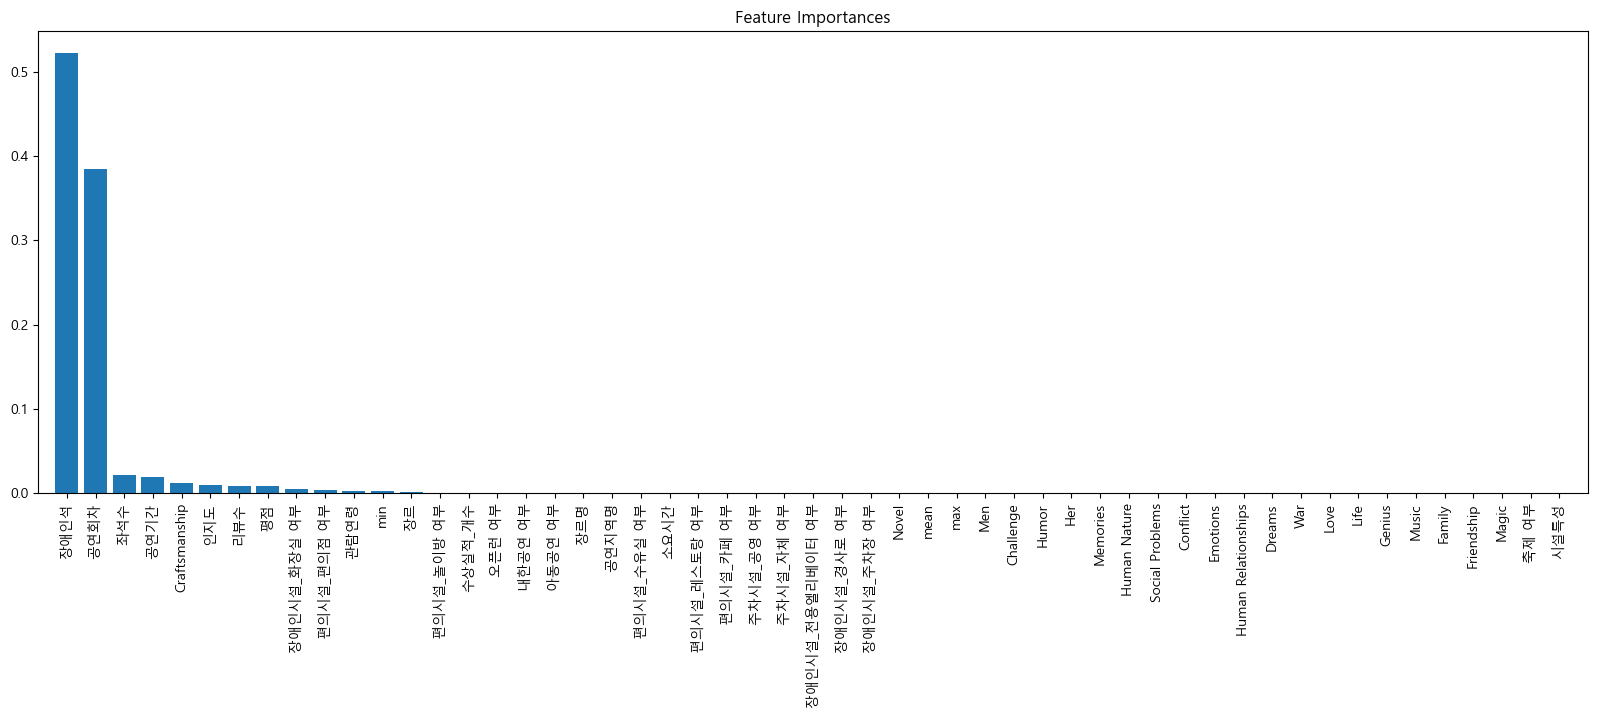

In [24]:
# feature_importance 생성

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin':  # MacOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (폰트를 직접 설정해야 할 수 있음)
    plt.rcParams['font.family'] = 'NanumGothic'

# 한글이 깨질 경우, 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 모델 학습 (cross_val_score는 교차 검증을 위한 것임을 고려하여, 실제 학습을 위해 전체 데이터를 사용)
model.fit(x_train_resampled, target_resampled)

# 특성 중요도 추출
importances = model.feature_importances_

# 특성 중요도를 내림차순으로 정렬하기 위해 인덱스를 정렬
indices = np.argsort(importances)[::-1]

# 특성 이름 가져오기
feature_names = x_train_resampled.columns

# 시각화
plt.figure(figsize=(20, 6))
plt.title("Feature Importances")
plt.bar(range(x_train_resampled.shape[1]), importances[indices], align="center")
plt.xticks(range(x_train_resampled.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, x_train_resampled.shape[1]])
plt.show()

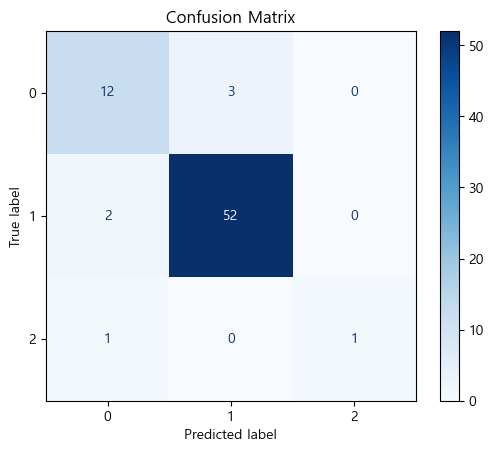

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

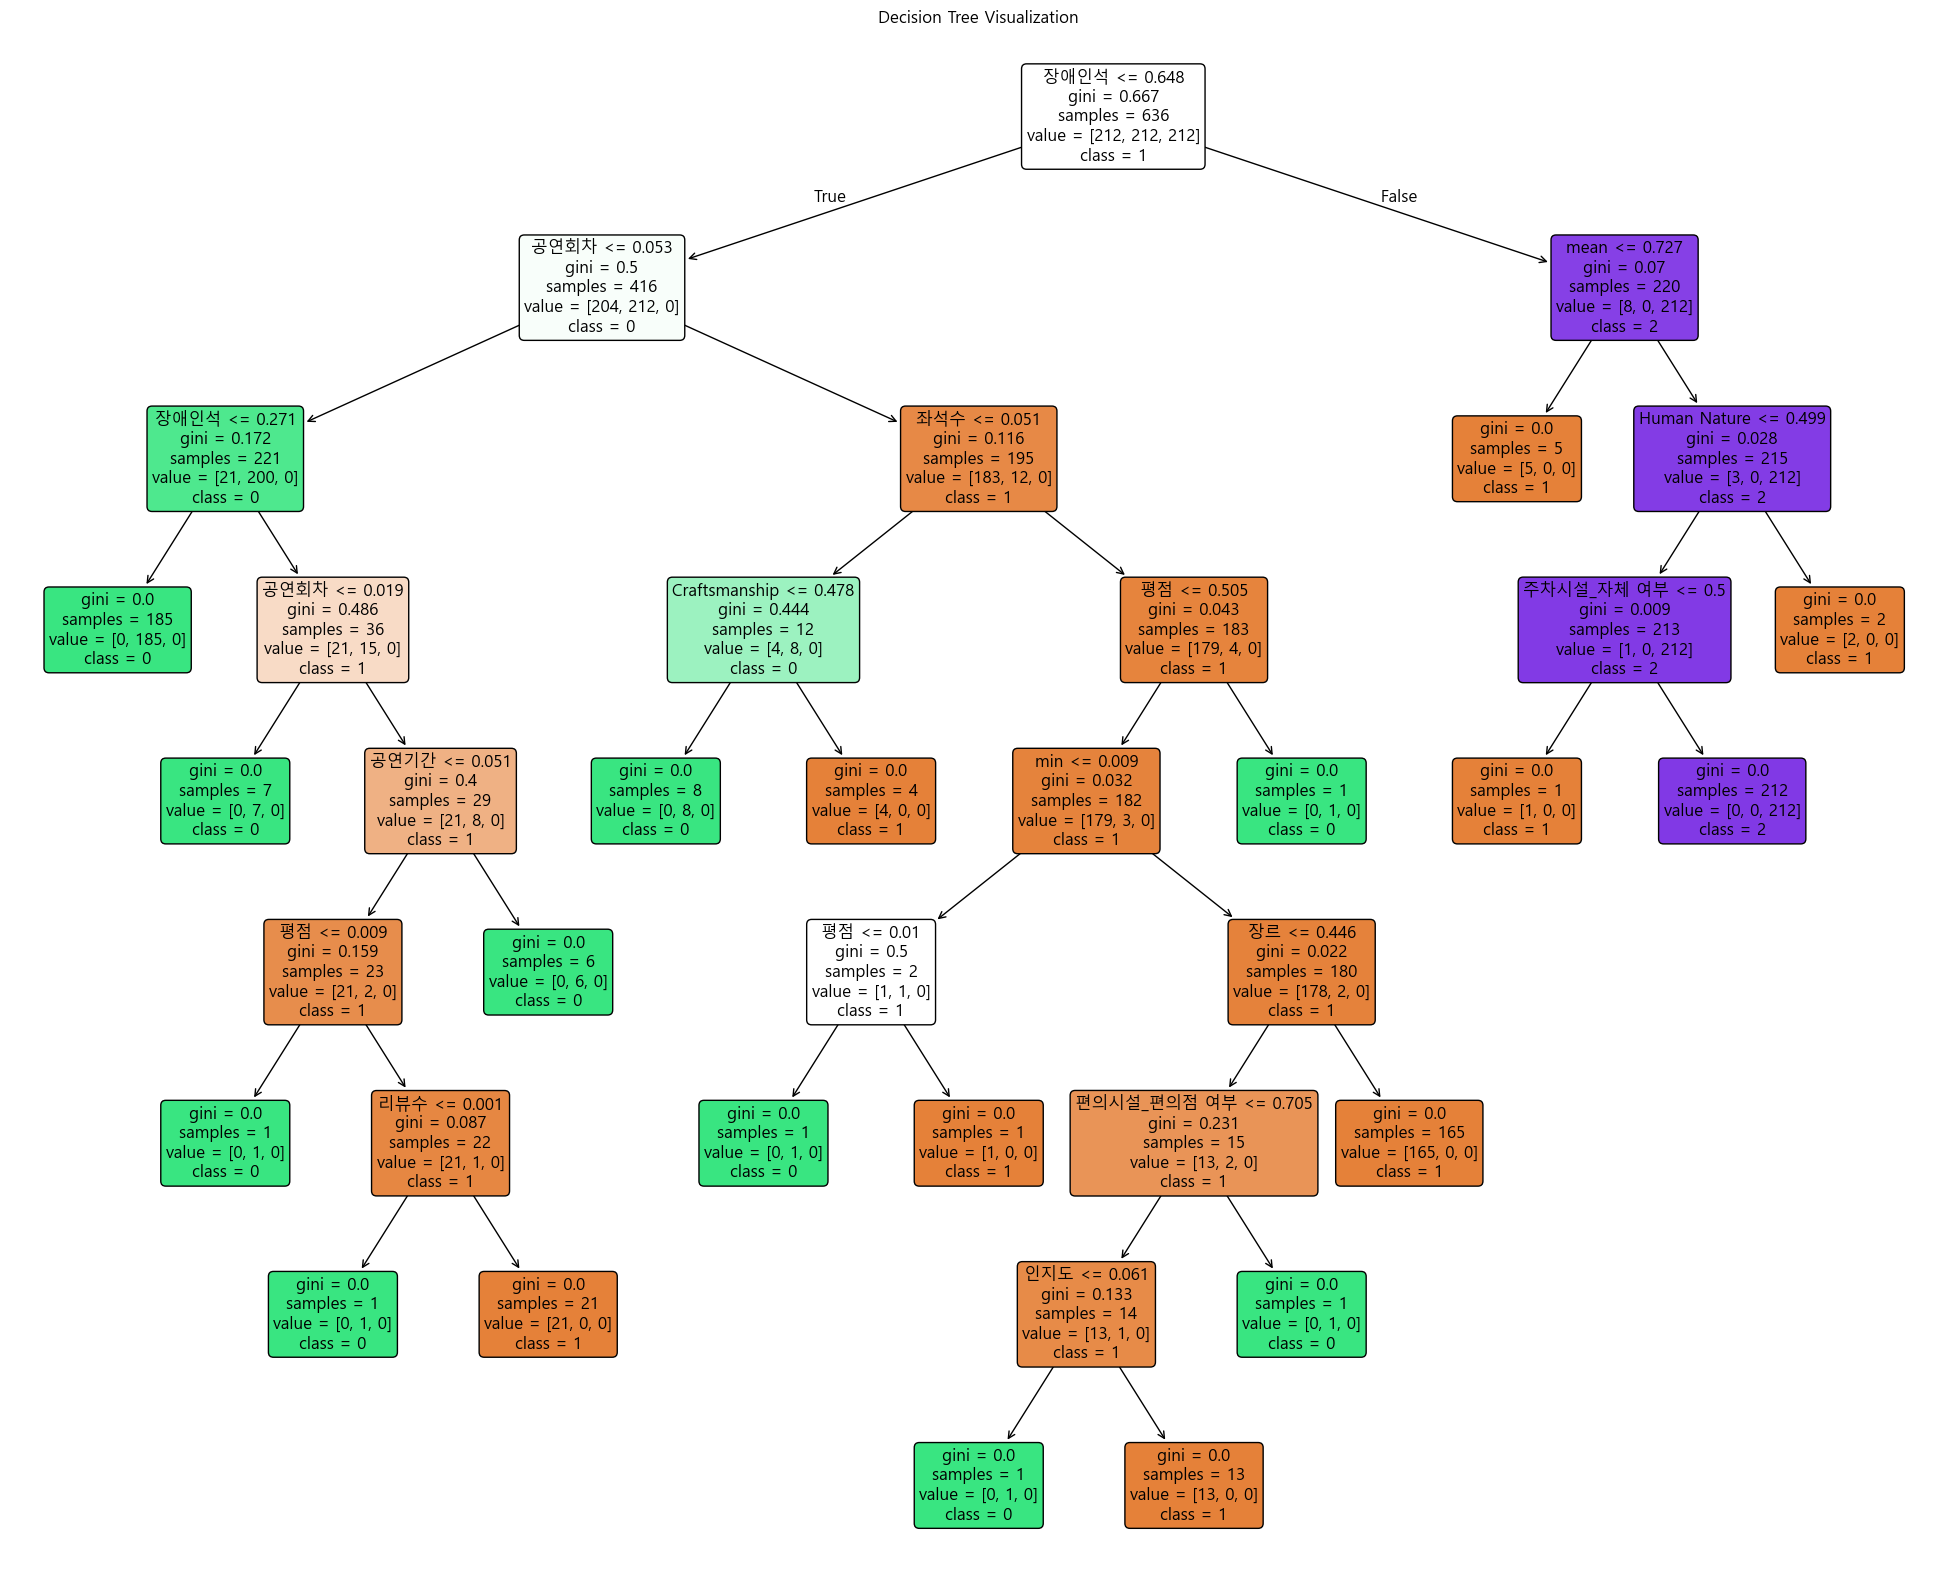

In [41]:
# 의사결정 나무 시각화

# 모델 객체 생성
model = DecisionTreeClassifier()  # DecisionTreeClassifier 초기화

# 전체 학습 데이터로 모델 학습
model.fit(x_train_resampled, target_resampled)  # 모델 학습

plt.figure(figsize=(25,20))  # 그래프의 크기를 조정합니다.
plot_tree(model, 
          feature_names=x_train_resampled.columns,  # 사용한 특성의 이름을 지정합니다.
          class_names=[str(cls) for cls in target_resampled.unique()],  # 클래스 이름을 문자열로 변환하여 지정합니다.
          filled=True,  # 노드를 채웁니다.
          rounded=True,  # 노드 모서리를 둥글게 만듭니다.
          fontsize=12)  # 글자 크기를 조정합니다.
plt.title("Decision Tree Visualization")
plt.show()

### 의사결정나무에 대해서 간단하게 해석 
- 첫 번째 노드에서는 장애인석 <= 0.648을 기준으로 분리하 행해진다.
- 0,1,2의 클래스 비율이 1:1:1에 해당하기 때문에 gini계수는 0.667에 해당한다.
- 첫 번째 노드에 samples의 개수는 636개이다.
- value는 클래스별 개수를 의미한다.
- class = 1은 해당 노드에서 가장 많이 예측한 것이 1임을 의미하는 것이다.